# Preparação

In [1]:
# Importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\danie\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [8]:
# Carregando os dados
df_train = pd.read_csv('Abandono_clientes.csv')
df_test = pd.read_csv('Abandono_teste.csv', sep=';')

In [10]:
df_train

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [9]:
df_test

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,10001,15798485,Copley,565,France,Male,31,1,0.00,1,0,1,20443.08
1,10002,15588959,T'ang,569,France,Male,34,4,0.00,1,0,1,4045.90
2,10003,15624896,Ku,669,France,Female,20,7,0.00,2,1,0,128838.67
3,10004,15639629,McConnan,694,France,Male,39,4,173255.48,1,1,1,81293.10
4,10005,15638852,Ts'ui,504,Spain,Male,28,10,109291.36,1,1,1,187593.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10996,15730373,Starks,531,France,Female,34,10,118306.79,1,1,0,26493.05
996,10997,15716191,Dixon,575,Germany,Male,49,2,136822.70,1,1,0,2487.74
997,10998,15673900,Wilkinson,520,France,Female,74,4,0.00,1,0,0,26742.92
998,10999,15581432,Oatley,675,Spain,Male,23,8,0.00,2,0,0,162342.21


# 1. Descrevendo os dados

In [13]:
# Visão geral dos dados de treinamento
print("Resumo do Dataset de Treinamento:")
print(df_train.info())

Resumo do Dataset de Treinamento:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [14]:
# Visão geral dos dados de teste
print("\nResumo do Dataset de Teste:")
print(df_test.info())


Resumo do Dataset de Teste:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        1000 non-null   int64  
 1   CustomerId       1000 non-null   int64  
 2   Surname          1000 non-null   object 
 3   CreditScore      1000 non-null   int64  
 4   Geography        1000 non-null   object 
 5   Gender           1000 non-null   object 
 6   Age              1000 non-null   int64  
 7   Tenure           1000 non-null   int64  
 8   Balance          1000 non-null   float64
 9   NumOfProducts    1000 non-null   int64  
 10  HasCrCard        1000 non-null   int64  
 11  IsActiveMember   1000 non-null   int64  
 12  EstimatedSalary  1000 non-null   float64
dtypes: float64(2), int64(8), object(3)
memory usage: 101.7+ KB
None


In [15]:
# Estatísticas Descritivas
print("\nEstatísticas descritivas - Variáveis numéricas do Dataset de Treinamento:")
print(df_train.describe())


Estatísticas descritivas - Variáveis numéricas do Dataset de Treinamento:
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.4052

In [30]:
# Selecionar as variáveis numéricas
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Calcular as estatísticas
stats = df_train[numerical_features].describe().T[['mean', 'std', 'min', 'max']]

# Renomear as colunas para o formato desejado
stats.columns = ['Média', 'Desv. padrão', 'Min', 'Max']

# Exibir a tabela
print(stats)

                         Média  Desv. padrão     Min        Max
CreditScore         650.528800     96.653299  350.00     850.00
Age                  38.921800     10.487806   18.00      92.00
Tenure                5.012800      2.892174    0.00      10.00
Balance           76485.889288  62397.405202    0.00  250898.09
NumOfProducts         1.530200      0.581654    1.00       4.00
EstimatedSalary  100090.239881  57510.492818   11.58  199992.48


In [16]:
# Verificando valores ausentes
print("\nValores ausentes no Dataset de Treinamento:")
print(df_train.isnull().sum())

print("\nValores ausentes no Dataset de Teste:")
print(df_test.isnull().sum())


Valores ausentes no Dataset de Treinamento:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Valores ausentes no Dataset de Teste:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64


In [26]:
# Contar a frequência de cada país na coluna 'Geography'
country_counts = df_train['Geography'].value_counts()
country_counts

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

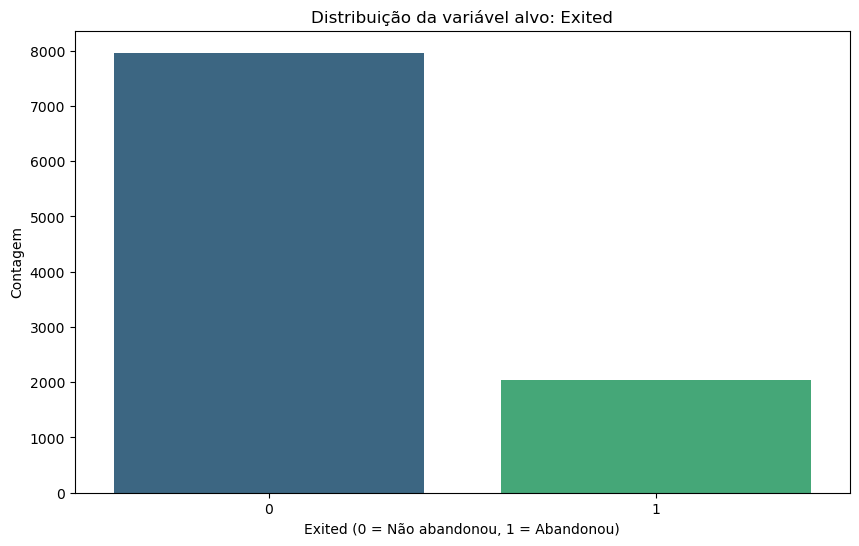

In [17]:
# Visualizações Gráficas
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='Exited', palette='viridis')
plt.title('Distribuição da variável alvo: Exited')
plt.xlabel('Exited (0 = Não abandonou, 1 = Abandonou)')
plt.ylabel('Contagem')
plt.show()

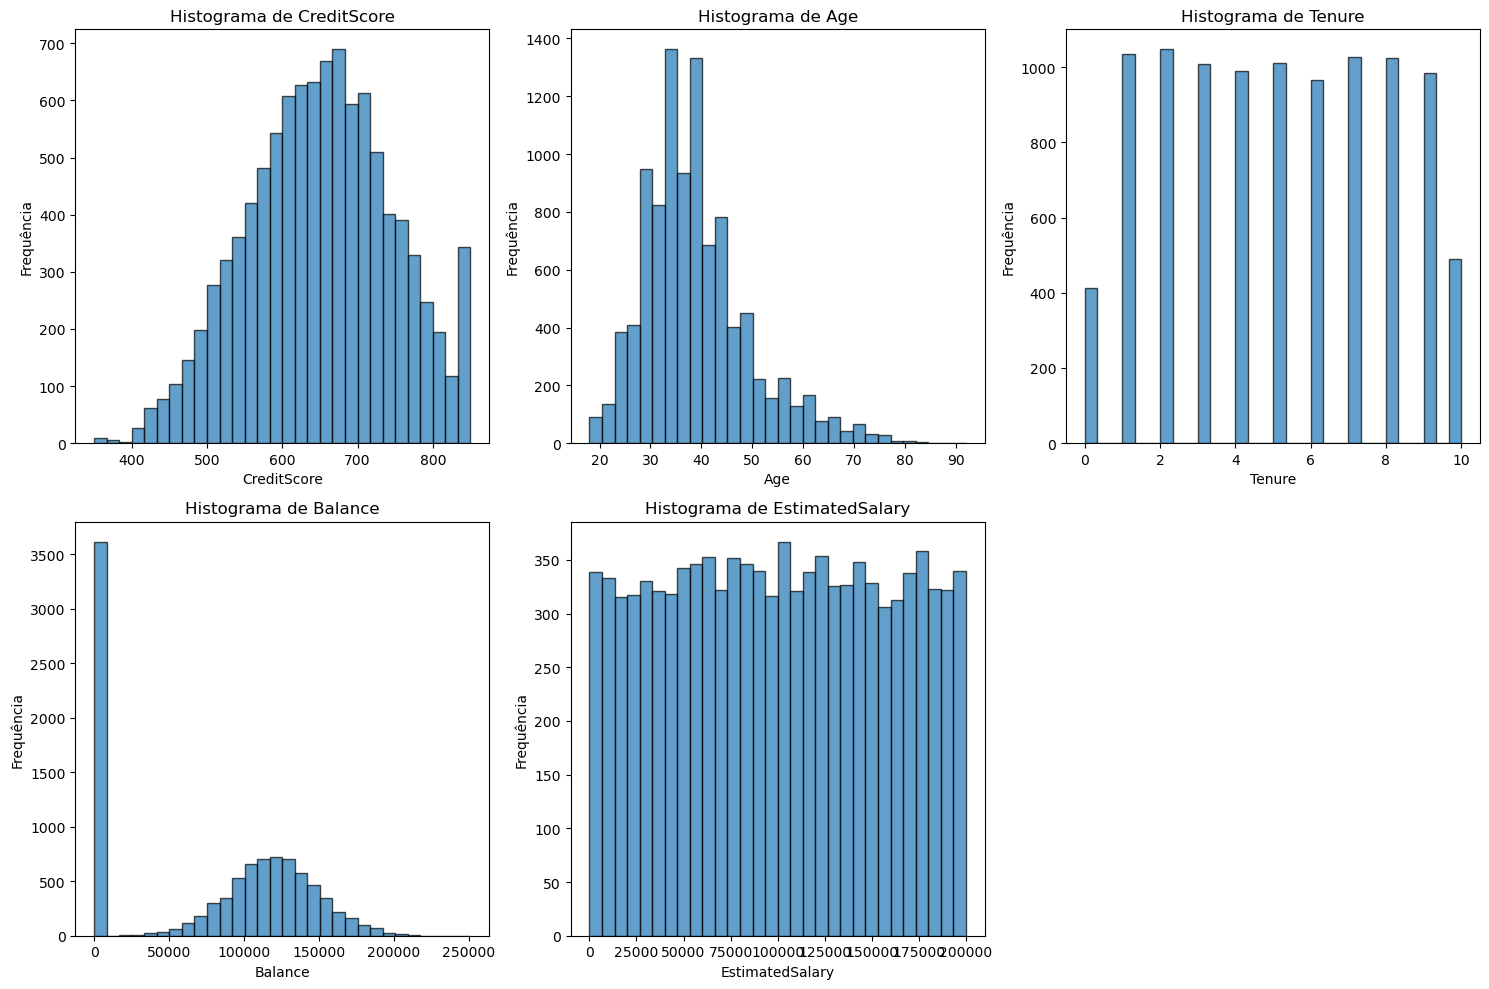

In [38]:
# Selecionar as variáveis numéricas
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

# Criar os histogramas
plt.figure(figsize=(15, 10))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)  # Cria uma grade de 2 linhas e 3 colunas
    plt.hist(df_train[feature], bins=30, edgecolor='black', alpha=0.7)
    plt.title(f'Histograma de {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequência')

# Ajustar o layout
plt.tight_layout()
plt.show()

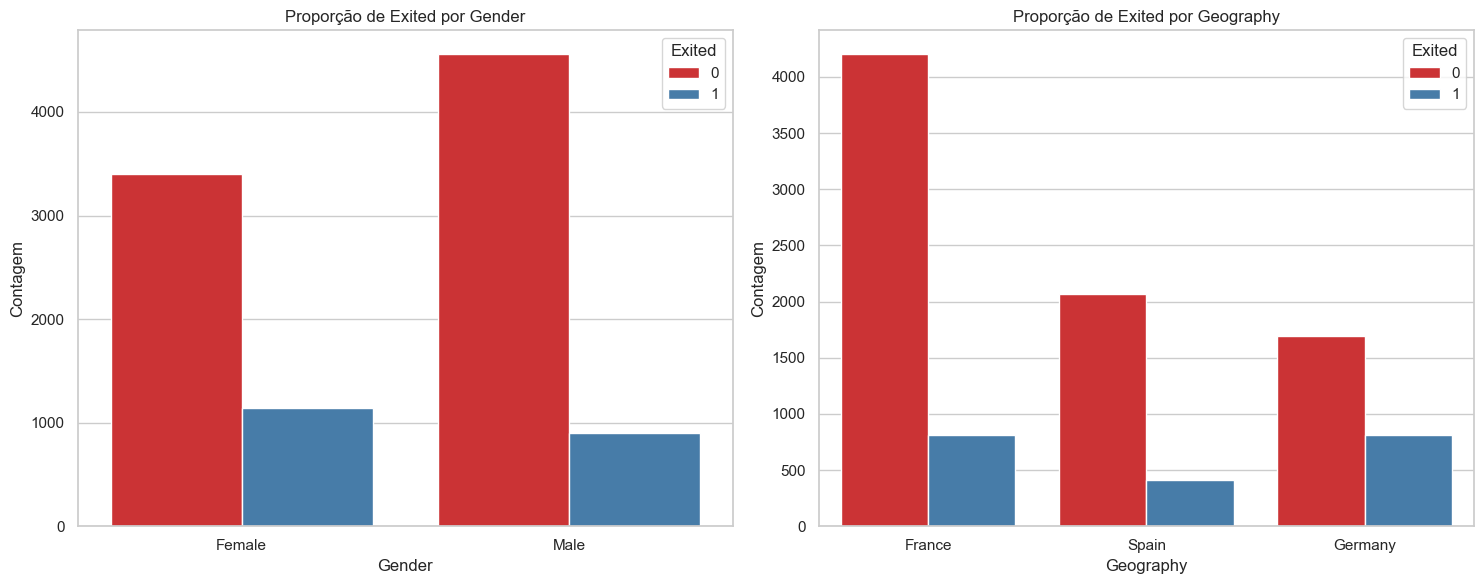

In [39]:
# Variáveis categóricas
categorical_features = ['Gender', 'Geography']
target = 'Exited'

# Configuração do estilo do gráfico
sns.set(style="whitegrid")

# Criar gráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico para 'Gender'
sns.countplot(x='Gender', hue=target, data=df_train, ax=axes[0], palette='Set1')
axes[0].set_title('Proporção de Exited por Gender')
axes[0].set_ylabel('Contagem')
axes[0].set_xlabel('Gender')

# Gráfico para 'Geography'
sns.countplot(x='Geography', hue=target, data=df_train, ax=axes[1], palette='Set1')
axes[1].set_title('Proporção de Exited por Geography')
axes[1].set_ylabel('Contagem')
axes[1].set_xlabel('Geography')

# Ajustar layout e mostrar o gráfico
plt.tight_layout()
plt.show()


Proporções de Exited por Gender:
        Não Exited     Exited
Gender                       
Female   74.928461  25.071539
Male     83.544072  16.455928

Proporções de Exited por Geography:
           Não Exited     Exited
Geography                       
France      83.845233  16.154767
Germany     67.556796  32.443204
Spain       83.326605  16.673395


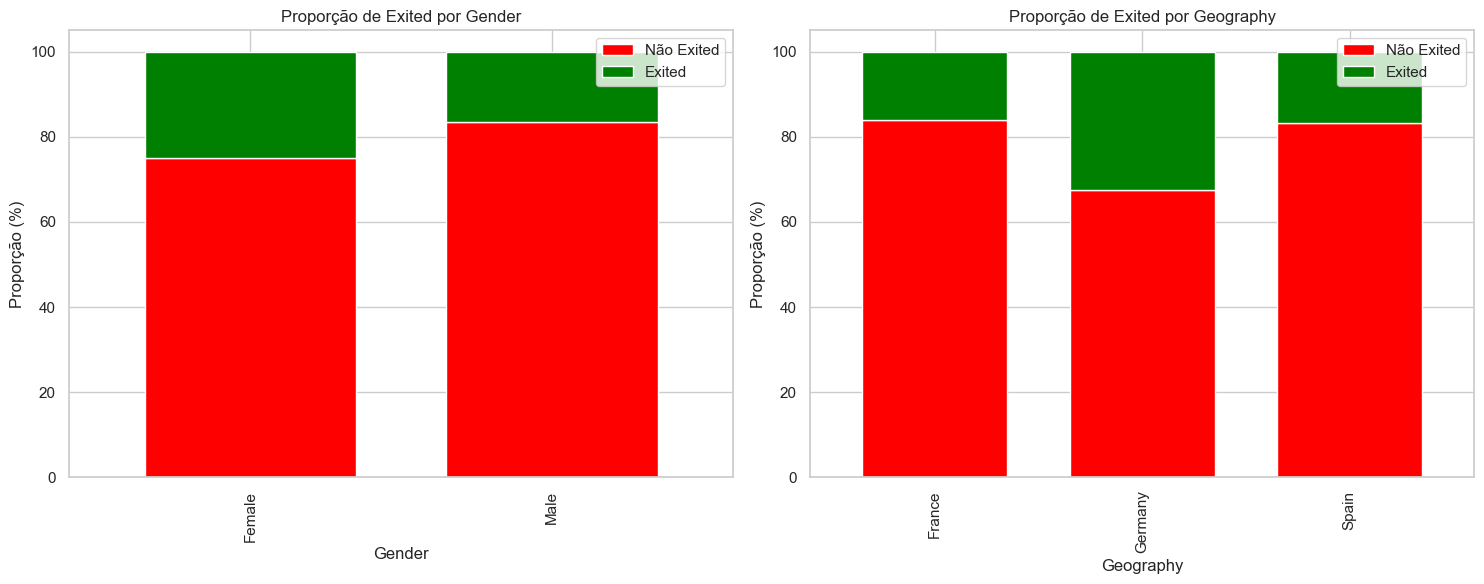

In [42]:
# Variáveis categóricas e target
categorical_features = ['Gender', 'Geography']
target = 'Exited'

# Calcular as proporções de Exited (1) vs Não Exited (0) por cada categoria
proportions = pd.DataFrame()

# Proporção para Gender
gender_proportions = df_train.groupby('Gender')[target].value_counts(normalize=True).unstack().fillna(0)
gender_proportions.columns = ['Não Exited', 'Exited']
gender_proportions = gender_proportions.apply(lambda x: x * 100, axis=1)

# Proporção para Geography
geography_proportions = df_train.groupby('Geography')[target].value_counts(normalize=True).unstack().fillna(0)
geography_proportions.columns = ['Não Exited', 'Exited']
geography_proportions = geography_proportions.apply(lambda x: x * 100, axis=1)

# Exibir as proporções
print("\nProporções de Exited por Gender:")
print(gender_proportions)
print("\nProporções de Exited por Geography:")
print(geography_proportions)

# Gráficos de proporção para Gender e Geography
sns.set(style="whitegrid")

# Criar gráfico para 'Gender'
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gender
gender_proportions.plot(kind='bar', stacked=True, ax=axes[0], color=['red', 'green'], width=0.7)
axes[0].set_title('Proporção de Exited por Gender')
axes[0].set_ylabel('Proporção (%)')
axes[0].set_xlabel('Gender')

# Geography
geography_proportions.plot(kind='bar', stacked=True, ax=axes[1], color=['red', 'green'], width=0.7)
axes[1].set_title('Proporção de Exited por Geography')
axes[1].set_ylabel('Proporção (%)')
axes[1].set_xlabel('Geography')

# Ajustar layout
plt.tight_layout()
plt.show()